## 1 Data Import and Libraries

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

dataset_path = kagglehub.dataset_download("bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset")
print(f"Data cached at: {dataset_path}")

df = pd.read_csv(f"{dataset_path}/healthcare_synthetic_data.csv")

c:\Users\LT-MSI\.conda\envs\ML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data cached at: C:\Users\LT-MSI\.cache\kagglehub\datasets\bertnardomariouskono\cardiovascular-disease-risk-prediction-dataset\versions\1


In [3]:
# =============================================================================
# FUNCTIONS FOR THRESHOLD OPTIMIZATION 
# =============================================================================

from sklearn.metrics import fbeta_score, recall_score, precision_score, f1_score, precision_recall_curve, average_precision_score

def find_optimal_threshold_f1(y_true, y_proba, n_thresholds=100):
    """Find the optimal threshold that maximizes the F1-score (same as in R)"""
    thresholds = np.linspace(0, 1, n_thresholds)
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            
    return best_threshold, best_f1

def evaluate_with_threshold(y_true, y_proba, threshold):
    """Evaluate a model with a given threshold"""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'f2': fbeta_score(y_true, y_pred, beta=2)
    }

In [4]:
df["Gender"] = pd.Categorical(df["Gender"], ordered=False)
df["Smoking_Status"] = pd.Categorical(df["Smoking_Status"], ordered=False)
df["Physical_Activity_Level"] = pd.Categorical(df["Physical_Activity_Level"], ordered=True)
df["Alcohol_Consumption"] = pd.Categorical(df["Alcohol_Consumption"], ordered=True)
df["Family_History"] = pd.Categorical(df["Family_History"], ordered=False)
df["Heart_Disease_Risk"] = pd.Categorical(df["Heart_Disease_Risk"], ordered=False)

# Modelling

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, make_scorer
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [7]:
df_model = df.drop(columns=["Patient_ID"])

labels_risk = ["Low risk", "High risk"]


## Variable Encoding: Stress_Level and Sleep_Hours

Before modeling, we need to decide how to treat `Stress_Level` and `Sleep_Hours`, which are ordinal variables that could be kept numeric or treated as categorical.

The EDA provided the following conclusions:

**For classification (Heart_Disease_Risk):**
- `Stress_Level` shows a clear **linear** relationship with the risk of heart disease: the higher the stress level, the higher the proportion of at-risk patients. It is therefore kept as a **numeric** variable.
- `Sleep_Hours` shows a **non-linear** (U-shaped) relationship: both very short and very long sleep durations are associated with higher risk. It is therefore treated as a **categorical** variable.

**For regression (Cholesterol_LDL):**
- The density plots from the EDA show that the distribution of `Cholesterol_LDL` is virtually identical across all levels of `Stress_Level` and all values of `Sleep_Hours`. Neither variable explains the target well.
- Both are therefore treated as **categorical** for regression. This avoids imposing a linear structure that is not supported by the data, without any meaningful loss of information.

Two separate encoded datasets are created accordingly: `df_encoded_classif` for classification and `df_encoded` for regression.

In [8]:
# For classification: Stress_Level is kept numeric (linear relationship with Heart_Disease_Risk),
# Sleep_Hours is treated as categorical (non-linear relationship)
df_model["Sleep_Hours"] = pd.Categorical(df_model["Sleep_Hours"])

df_encoded_classif = pd.get_dummies(df_model,
                             columns=["Gender", "Smoking_Status", "Physical_Activity_Level",
                                      "Alcohol_Consumption", "Family_History",
                                      "Sleep_Hours"],
                             drop_first=True)

print(f"Classification encoded data dimensions: {df_encoded_classif.shape}")

# For regression: both Stress_Level and Sleep_Hours are treated as categorical
# (no clear linear relationship with Cholesterol_LDL as shown by EDA density plots)
df_model["Stress_Level"] = pd.Categorical(df_model["Stress_Level"])

df_encoded = pd.get_dummies(df_model,
                             columns=["Gender", "Smoking_Status", "Physical_Activity_Level",
                                      "Alcohol_Consumption", "Family_History",
                                      "Stress_Level", "Sleep_Hours"],
                             drop_first=True)

print(f"Regression encoded data dimensions: {df_encoded.shape}")


Classification encoded data dimensions: (15000, 26)
Regression encoded data dimensions: (15000, 34)


In [9]:
numeric_features_classif = df_encoded_classif.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_classif = df_encoded_classif.select_dtypes(include=['category']).columns.tolist

In [10]:
numeric_features_classif

['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Systolic_BP',
 'Diastolic_BP',
 'Cholesterol_Total',
 'Cholesterol_LDL',
 'Cholesterol_HDL',
 'Fasting_Blood_Sugar',
 'Stress_Level']

In [11]:
# Create train, validation and test sets for classification

y_classif = df_encoded_classif["Heart_Disease_Risk"].cat.codes.values
X_classif = df_encoded_classif.drop(columns=["Heart_Disease_Risk"])
feature_names_classif = df_encoded_classif.drop(columns=["Heart_Disease_Risk"]).columns

Xtrain_c, Xtest_c, ytrain_c, ytest_c = train_test_split(
    X_classif, y_classif, test_size=0.3, random_state=42, stratify=y_classif)

Xval_c, Xtest_c, yval_c, ytest_c = train_test_split(
    Xtest_c, ytest_c, test_size=0.5, random_state=42, stratify=ytest_c)

scaler_c = StandardScaler()
Xtrain_c_sc = Xtrain_c.copy()
Xtest_c_sc  = Xtest_c.copy()
Xval_c_sc   = Xval_c.copy()
Xtrain_c_sc[numeric_features_classif] = scaler_c.fit_transform(Xtrain_c[numeric_features_classif])
Xtest_c_sc[numeric_features_classif] = scaler_c.transform(Xtest_c[numeric_features_classif])
Xval_c_sc[numeric_features_classif] = scaler_c.transform(Xval_c[numeric_features_classif])

print("Training set:", Xtrain_c.shape[0], "observations")
print("Test set:     ", Xtest_c.shape[0], "observations")
print("Validation set:", Xval_c.shape[0], "observations")

Training set: 10500 observations
Test set:      2250 observations
Validation set: 2250 observations


In [12]:
Xtrain_c_sc

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Gender_1,Smoking_Status_1,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Alcohol_Consumption_1,Alcohol_Consumption_2,Family_History_1,Sleep_Hours_5,Sleep_Hours_6,Sleep_Hours_7,Sleep_Hours_8,Sleep_Hours_9,Sleep_Hours_10
10926,-0.803153,1.072954,0.509727,-0.139569,-1.074756,-0.773355,0.383890,0.714764,0.616758,-0.825081,-1.225279,True,False,False,True,False,True,False,False,False,True,False,False,False,False
8298,-0.213307,1.508378,0.474529,-0.451989,-2.311685,-2.064236,0.735307,0.603126,-0.564002,-1.933918,-0.182221,True,True,False,False,False,True,False,True,False,False,True,False,False,False
3493,-0.550362,-0.679627,-1.735917,-1.773769,-0.279588,-0.303944,-1.197487,-2.132000,1.122799,-1.346886,1.556210,False,True,True,False,False,True,False,False,False,True,False,False,False,False
2775,-0.297571,-0.157119,-0.771486,-0.860539,-0.014532,-0.421297,-0.582507,-0.122520,0.448078,1.131691,0.165466,True,False,False,False,False,True,False,False,False,False,False,False,False,False
9775,1.640493,-1.746416,-0.482861,0.773661,0.515580,0.517526,0.823161,0.156575,-1.407402,-0.433726,0.165466,False,False,False,True,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,-1.561526,0.953213,-0.518060,-1.221025,-0.014532,-0.069238,-0.582507,-1.238898,-0.395322,0.022854,-1.572966,True,False,False,False,False,True,False,False,False,False,True,False,False,False
8690,0.545066,-0.799369,-0.074562,0.557370,-0.544644,0.165467,0.252108,-0.010882,0.279398,2.240528,-1.225279,False,True,False,False,False,False,False,False,False,True,False,False,False,False
1081,-0.381835,-0.516343,0.270380,0.773661,1.575805,1.338996,-0.362872,-1.238898,-0.901362,-1.151209,1.208524,False,True,False,True,False,False,False,False,False,False,True,False,False,False
9221,-0.213307,-0.701399,-0.489901,-0.091504,-0.632996,0.634879,-0.143236,0.156575,0.110718,0.805563,0.165466,False,False,True,False,False,True,False,False,False,False,True,False,False,False


The dataset is split into a training set (70%), validation set (15%) and a test set (15%). This step is essential to evaluate model performance on unseen data and avoid overfitting. The split is stratified on `Heart_Disease_Risk` to ensure a balanced class distribution in both sets. The reason why validation set is necessary will be explained in the next section.

Quantitative variables are standardized (centering and scaling) using parameters estimated **only on the training set**, then applied to the test set, which avoids any data leakage.

# 1 Prediction of Heart Disease Risk, `Heart_Disease_Risk`

To compare the efficiency of each method, we use the **F1-score** as the main metric, which balances precision and recall. Accuracy alone is insufficient in a medical context: classifying a at-risk patient as healthy (false negative) is far more costly than the opposite.

To maximize F1 score, there are several approaches : 
- For CV, use F1 score as the metric to evaluate the model
- Change the class weight, which is not always possible
- Choose threshold for the probability on the validation set

Those methods will be performed at the same time if possible in order to have the best model. For the choice of threshold, this step must be performed on the validation. If we do this on the training, the threshold is overly optimistic since the models are trained on the same data. On the contrary, we must not perform anything on the test set execpt the last step, when we evaluate the models. Hence, in this section the validation set is necessary for our approach.

## 1.1 Linear Models

### 1.1.1 Logistic Regression

#### Without regularization

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict


ts = time.time()
logit = LogisticRegression(solver='liblinear', max_iter=1000)
logit.fit(Xtrain_c_sc, ytrain_c)

te = time.time()

# Choose threshold using only validation predictions
y_val_proba = logit.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1_cv = find_optimal_threshold_f1(yval_c, y_val_proba)

print("Best threshold from validation set:", best_threshold)
print("Best validation F1:", best_f1_cv)

# predictions on test set
y_proba_logit = logit.predict_proba(Xtest_c_sc)[:, 1]
metrics_logit = evaluate_with_threshold(ytest_c, y_proba_logit, best_threshold)

print("Logistic Regression")
print(f"Execution time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_logit['recall']:.4f}")
print(f"Precision : {metrics_logit['precision']:.4f}")
print(f"F1-score : {metrics_logit['f1']:.4f}")
print(f"F2-score : {metrics_logit['f2']:.4f}")

y_pred_opt = (y_proba_logit >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)

Best threshold from validation set: 0.36363636363636365
Best validation F1: 0.7070330693991617
Logistic Regression
Execution time: 0.04 seconds
Optimal threshold: 0.3636
Recall : 0.7757
Precision : 0.6279
F1-score : 0.6940
F2-score : 0.7408

Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,818,451
High risk,220,761


The logistic regression without regularization serves as our baseline model. The coefficients allow us to identify the most influential variables. The optimal threshold is determined by maximizing the F1-score on the training set.


#### Ridge regularization (L2)

In [14]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50]}]
f1_scorer = make_scorer(f1_score)
logit_ridge = GridSearchCV(LogisticRegression(penalty="l2", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=-1, scoring=f1_scorer)
logitRidgeOpt = logit_ridge.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

print("Ridge Logistic Regression")
print(f"Best validation score = {logitRidgeOpt.best_score_:.4f}, Best parameter = {logitRidgeOpt.best_params_}")
print(f"Time: {te-ts:.2f} seconds")

y_proba_ridge_val = logitRidgeOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_ridge_val)

y_proba_ridge = logitRidgeOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_ridge = evaluate_with_threshold(ytest_c, y_proba_ridge, best_threshold)

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_ridge['recall']:.4f}")
print(f"Precision : {metrics_ridge['precision']:.4f}")
print(f"F1-score : {metrics_ridge['f1']:.4f}")
print(f"F2-score : {metrics_ridge['f2']:.4f}")


Ridge Logistic Regression
Best validation score = 0.6851, Best parameter = {'C': 1}
Time: 12.79 seconds
Optimal threshold: 0.3636
Recall : 0.7757
Precision : 0.6279
F1-score : 0.6940
F2-score : 0.7408


In [15]:
y_pred_opt = (y_proba_ridge >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,818,451
High risk,220,761


Ridge regularization penalizes the coefficients without setting any to zero. The hyperparameter `C` is optimized by 5-fold cross-validation. A low `C` corresponds to strong regularization.

#### LASSO regularization (L1) and variable selection

*Note*: execution may take a while.

In [16]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]}]
logit_lasso = GridSearchCV(LogisticRegression(penalty="l1", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=-1, scoring=f1_scorer)
logitLassoOpt = logit_lasso.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

print("LASSO Logistic Regression")
print(f"Best CV score = {logitLassoOpt.best_score_:.4f}, Best parameter = {logitLassoOpt.best_params_}")
print(f"Time: {te-ts:.2f} seconds")

y_proba_lasso_val = logitLassoOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_lasso_val)

y_proba_lasso = logitLassoOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_lasso = evaluate_with_threshold(ytest_c, y_proba_lasso, best_threshold)

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_lasso['recall']:.4f}")
print(f"Precision : {metrics_lasso['precision']:.4f}")
print(f"F1-score : {metrics_lasso['f1']:.4f}")
print(f"F2-score : {metrics_lasso['f2']:.4f}")


LASSO Logistic Regression
Best CV score = 0.6849, Best parameter = {'C': 100}
Time: 1.34 seconds
Optimal threshold: 0.3535
Recall : 0.7870
Precision : 0.6236
F1-score : 0.6958
F2-score : 0.7478


In [17]:
y_pred_opt = (y_proba_lasso >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,803,466
High risk,209,772


In [18]:
coef = logitLassoOpt.best_estimator_.coef_[0]
variables_selectionnees = feature_names_classif[coef != 0]
print(f"\nVariables selected by LASSO ({len(variables_selectionnees)} / {len(feature_names_classif)}):")
print(variables_selectionnees.tolist())


Variables selected by LASSO (25 / 25):
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1', 'Physical_Activity_Level_2', 'Physical_Activity_Level_3', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10']


The LASSO selects all 33 variables, meaning the regularization is not strong enough to eliminate any predictor. This is consistent with the EDA: many variables contribute to heart disease risk. In particular, Smoking_Status, Family_History, Physical_Activity_Level and Stress_Level were identified as the most important in the EDA, and they are all retained here.

LASSO regularization performs variable selection by setting some coefficients to zero. The retained variables are consistent with the exploratory analysis: smoking status, family history, physical activity level, stress and LDL cholesterol stand out as the most discriminating.

## 1.2 kNN

### k-Nearest Neighbors (classification)

The k-nearest neighbors algorithm (kNN) is a non-parametric method with no assumption on the data distribution. The hyperparameter `k` is optimized by 10-fold cross-validation. Data is standardized beforehand, which is essential for this distance-based method.

In [22]:
from sklearn.neighbors import KNeighborsClassifier

ts = time.time()
param_grid = [{"n_neighbors": list(range(1, 100))}]
knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, n_jobs=-1, scoring=f1_scorer)
knnOpt = knn.fit(Xtrain_c_sc, ytrain_c)  # kNN requires standardized data
te = time.time()
print("Best validation score = %f, Best parameter = %s" % (knnOpt.best_score_, knnOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best validation score = 0.571528, Best parameter = {'n_neighbors': 27}
Time: 20.67 seconds


In [23]:
y_proba_knn_val = knnOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_knn_val)

y_proba_knn = knnOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_knn = evaluate_with_threshold(ytest_c, y_proba_knn, best_threshold)

print("kNN")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall    : {metrics_knn['recall']:.4f}")
print(f"Precision : {metrics_knn['precision']:.4f}")
print(f"F1-score  : {metrics_knn['f1']:.4f}")
print(f"F2-score  : {metrics_knn['f2']:.4f}")

kNN
Optimal threshold: 0.3030
Recall    : 0.8461
Precision : 0.5240
F1-score  : 0.6472
F2-score  : 0.7534


In [24]:
y_pred_opt = (y_proba_knn >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,515,754
High risk,151,830


The optimized kNN uses standardized data. The optimal hyperparameter `k` is determined by 10-fold cross-validation.

## 1.2.2 kNN with Fewer Variables

In [25]:
df_encoded_knn = df_encoded_classif.copy()
df_encoded_knn = df_encoded_knn.drop(columns= ['Height_cm', 'Weight_kg', 'BMI', 'Diastolic_BP', 'Cholesterol_HDL',
       'Heart_Disease_Risk', 'Gender_1',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2',
       'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10'])

# Here we keep the Variables: SmokingStatus, Stress Level (numeric), Family history, Cholesterol LDL, 
# Cholesterol Total, Physical Activity Level as they are the variables correlated to Heart Disease Risk
# as retrieved in LDA and MCA

print(df_encoded_knn.columns)
X_knn = df_encoded_knn
numeric_features_classif_knn = df_encoded_knn.select_dtypes(include=[np.number]).columns.tolist()
Xtrain_knn, Xtest_knn, ytrain_c, ytest_c = train_test_split(
    X_knn, y_classif, test_size=0.3, random_state=42, stratify=y_classif)

Xval_knn, Xtest_knn, yval_c, ytest_c = train_test_split(
    Xtest_knn, ytest_c, test_size=0.5, random_state=42, stratify=ytest_c)

scaler_c = StandardScaler()
Xtrain_knn_sc = Xtrain_knn.copy()
Xtest_knn_sc  = Xtest_knn.copy()
Xval_knn_sc   = Xval_knn.copy()
Xtrain_knn_sc[numeric_features_classif_knn] = scaler_c.fit_transform(Xtrain_knn[numeric_features_classif_knn])
Xtest_knn_sc[numeric_features_classif_knn]  = scaler_c.transform(Xtest_knn[numeric_features_classif_knn])
Xval_knn_sc[numeric_features_classif_knn]   = scaler_c.transform(Xval_knn[numeric_features_classif_knn])

Xtrain_knn_sc.shape


Index(['Age', 'Systolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL',
       'Fasting_Blood_Sugar', 'Stress_Level', 'Smoking_Status_1',
       'Physical_Activity_Level_1', 'Physical_Activity_Level_2',
       'Physical_Activity_Level_3', 'Family_History_1'],
      dtype='object')


(10500, 11)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

ts = time.time()
param_grid = [{"n_neighbors": list(range(1, 100))}]
knn_var = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, n_jobs=-1, scoring=f1_scorer)
knn_var_Opt = knn_var.fit(Xtrain_knn_sc, ytrain_c)  # kNN requires standardized data
te = time.time()
print("Best score = %f, Best parameter = %s" % (knn_var_Opt.best_score_, knn_var_Opt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best score = 0.628807, Best parameter = {'n_neighbors': 11}
Time: 28.92 seconds


In [27]:
y_proba_knn_var_val = knn_var_Opt.predict_proba(Xval_knn_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_knn_var_val)

y_proba_knn_var = knn_var_Opt.predict_proba(Xtest_knn_sc)[:, 1]
metrics_knn_var = evaluate_with_threshold(ytest_c, y_proba_knn_var, best_threshold)

print("kNN_var")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall    : {metrics_knn_var['recall']:.4f}")
print(f"Precision : {metrics_knn_var['precision']:.4f}")
print(f"F1-score  : {metrics_knn_var['f1']:.4f}")
print(f"F2-score  : {metrics_knn_var['f2']:.4f}")

kNN_var
Optimal threshold: 0.2727
Recall    : 0.7798
Precision : 0.5787
F1-score  : 0.6644
F2-score  : 0.7291


In [28]:
y_pred_opt = (y_proba_knn_var >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,712,557
High risk,216,765


Dropping uncorrelated variables does help a little. The results still remain behind the other models.

By reducing the number of variables to those most correlated with `Heart_Disease_Risk` (identified by PCA and MCA), kNN performance improves slightly. This confirms that some uninformative variables add noise to the distance computation.

## 1.3 SVM

### 1.3.1 Linear SVM


The Support Vector Machine (SVM) seeks the maximum-margin separating hyperplane. Two variants are compared: a linear SVM and a Gaussian kernel SVM (RBF), which can capture non-linear decision boundaries. The RBF kernel is justified by the presence of non-linear relationships observed in the EDA. The hyperparameters `C` (margin), `gamma` (kernel width), and `class_weight`  are optimized by cross-validation. Data is standardized beforehand.

In [29]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

ts = time.time()
svm_linear = LinearSVC(max_iter=5000, random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_linear, method='sigmoid', cv=5, n_jobs=-1)
svm_calibrated.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_svm_lin_val = svm_calibrated.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_svm_lin_val)

y_proba_svm_lin = svm_calibrated.predict_proba(Xtest_c_sc)[:, 1]
metrics_svm_lin = evaluate_with_threshold(ytest_c, y_proba_svm_lin, best_threshold)

print("Linear SVM")
print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_svm_lin['recall']:.4f}")
print(f"Precision : {metrics_svm_lin['precision']:.4f}")
print(f"F1-score : {metrics_svm_lin['f1']:.4f}")
print(f"F2-score : {metrics_svm_lin['f2']:.4f}")



Linear SVM
Time: 0.09 seconds
Optimal threshold: 0.3535
Recall : 0.7778
Precision : 0.6229
F1-score : 0.6917
F2-score : 0.7409


In [30]:
y_pred_opt = (y_proba_svm_lin >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,807,462
High risk,218,763


The linear SVM is calibrated via `CalibratedClassifierCV` to obtain probabilities, which allows threshold optimization. Its performance is comparable to logistic regression, which is expected for a linear model.

#### CV

The hyperparameters `C` and `class_weight` will be optimized using CV 5-fold.

In [31]:
param = [{"C": [0.1, 1,2, 5,10],     
          "class_weight": [
                None,
                "balanced",
                {0: 1, 1: 1.5},
                {0: 1, 1: 2},
                {0: 1, 1: 2.5},
                {0: 1, 1: 3}
            ]
        }]
svm = GridSearchCV(LinearSVC(), param, cv=5, n_jobs=-1, scoring=f1_scorer)
svm_linear_opt = svm.fit(Xtrain_c_sc, ytrain_c)

In [32]:
svm.best_params_

{'C': 0.1, 'class_weight': {0: 1, 1: 2}}

In [33]:
svm_calibrated_opt = CalibratedClassifierCV(svm_linear_opt.best_estimator_, method='sigmoid', cv=5, n_jobs=-1)
svm_calibrated_opt.fit(Xtrain_c_sc, ytrain_c)

y_proba_svm_lin_opt_val = svm_calibrated_opt.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_svm_lin_opt_val)

y_proba_svm_lin_opt = svm_calibrated_opt.predict_proba(Xtest_c_sc)[:, 1]
metrics_svm_lin_opt = evaluate_with_threshold(ytest_c, y_proba_svm_lin_opt, best_threshold)

print("Linear SVM CV")
#print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_svm_lin_opt['recall']:.4f}")
print(f"Precision : {metrics_svm_lin_opt['precision']:.4f}")
print(f"F1-score : {metrics_svm_lin_opt['f1']:.4f}")
print(f"F2-score : {metrics_svm_lin_opt['f2']:.4f}")

Linear SVM CV
Optimal threshold: 0.3636
Recall : 0.7768
Precision : 0.6282
F1-score : 0.6946
F2-score : 0.7417


### 1.3.2 Gaussian Kernel SVM

In [34]:
from sklearn.svm import SVC

ts = time.time()
svm_rbf = SVC(C=5, gamma=0.01, probability=True, random_state=42)
svm_rbf.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_svm_rbf_val = svm_rbf.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_svm_rbf_val)

y_proba_svm_rbf = svm_rbf.predict_proba(Xtest_c_sc)[:, 1]
metrics_svm_rbf = evaluate_with_threshold(ytest_c, y_proba_svm_rbf, best_threshold)

print("Gaussian kernel SVM (optimized)")
print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_svm_rbf['recall']:.4f}")
print(f"Precision : {metrics_svm_rbf['precision']:.4f}")
print(f"F1-score : {metrics_svm_rbf['f1']:.4f}")
print(f"F2-score : {metrics_svm_rbf['f2']:.4f}")

Gaussian kernel SVM (optimized)
Time: 22.79 seconds
Optimal threshold: 0.3030
Recall : 0.7584
Precision : 0.6305
F1-score : 0.6886
F2-score : 0.7288


In [50]:
y_pred_opt = (y_proba_svm_rbf >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,833,436
High risk,237,744


Hyperparameter search by cross-validation:

In [127]:
ts = time.time()
param = [{"C": [0.1, 1, 5, 10], "gamma": [0.01, 1.0/26, 0.05],
          "class_weight": [
                None,
                "balanced",
                {0: 1, 1: 1.5},
                {0: 1, 1: 2},
                {0: 1, 1: 2.5},
                {0: 1, 1: 3}
            ]}]
svm = GridSearchCV(SVC(), param, cv=5, n_jobs=-1, scoring=f1_scorer)
svmOpt = svm.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Best score = %f, Best parameter = %s" % (svmOpt.best_score_, svmOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best score = 0.708357, Best parameter = {'C': 1, 'class_weight': {0: 1, 1: 2}, 'gamma': 0.01}
Time: 390.63 seconds


In [128]:
ts = time.time()
svm_rbf = SVC(C=1, gamma=0.01, class_weight={0: 1, 1: 2}, probability=True, random_state=42)
svm_rbf.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_svm_rbf_val = svm_rbf.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_svm_rbf_val)

y_proba_svm_rbf = svm_rbf.predict_proba(Xtest_c_sc)[:, 1]
metrics_svm_rbf = evaluate_with_threshold(ytest_c, y_proba_svm_rbf, best_threshold)

print("Gaussian kernel SVM (optimized)")
print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_svm_rbf['recall']:.4f}")
print(f"Precision : {metrics_svm_rbf['precision']:.4f}")
print(f"F1-score : {metrics_svm_rbf['f1']:.4f}")
print(f"F2-score : {metrics_svm_rbf['f2']:.4f}")

Gaussian kernel SVM (optimized)
Time: 24.77 seconds
Optimal threshold: 0.3636
Recall : 0.7798
Precision : 0.6194
F1-score : 0.6904
F2-score : 0.7414


In [130]:
y_pred_opt = (y_proba_svm_rbf >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,799,470
High risk,216,765


## 1.4 Optimal Decision Tree

The decision tree recursively partitions the variable space according to binary rules. Its main advantage is **interpretability**: the learned rules are directly readable. The maximum depth `max_depth` and `class_weight` are the main hyperparameters, optimized by 5-fold cross-validation to control overfitting.

In [131]:
from sklearn.tree import DecisionTreeClassifier

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None], "class_weight": [
                None,
                "balanced",
                {0: 1, 1: 1.5},
                {0: 1, 1: 2},
                {0: 1, 1: 2.5},
                {0: 1, 1: 3}
            ]}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param, cv=5, n_jobs=-1, scoring=f1_scorer)
treeOpt = tree.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Best score = %f, Best parameter = %s" % (treeOpt.best_score_, treeOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best score = 0.673683, Best parameter = {'class_weight': {0: 1, 1: 2}, 'max_depth': 5}
Time: 4.64 seconds


In [132]:
yChap = treeOpt.predict(Xtest_c_sc)
print("Score on test set: %f" % treeOpt.score(Xtest_c_sc, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score on test set: 0.654275


,Low risk,High risk
Low risk,621,648
High risk,189,792


In [133]:
y_proba_tree_opt_val = treeOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_tree_opt_val)
y_proba_tree_opt = treeOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_tree_opt = evaluate_with_threshold(ytest_c, y_proba_tree_opt, best_threshold)
print("Decision Tree (optimized)")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_tree_opt['recall']:.4f}")
print(f"Precision : {metrics_tree_opt['precision']:.4f}")
print(f"F1-score : {metrics_tree_opt['f1']:.4f}")
print(f"F2-score : {metrics_tree_opt['f2']:.4f}")

Decision Tree (optimized)
Optimal threshold: 0.5051
Recall : 0.8073
Precision : 0.5500
F1-score : 0.6543
F2-score : 0.7383


In [134]:
y_pred_opt = (y_proba_tree_opt >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,621,648
High risk,189,792


The decision tree with the optimal depth is displayed to interpret the decision rules learned by the model.

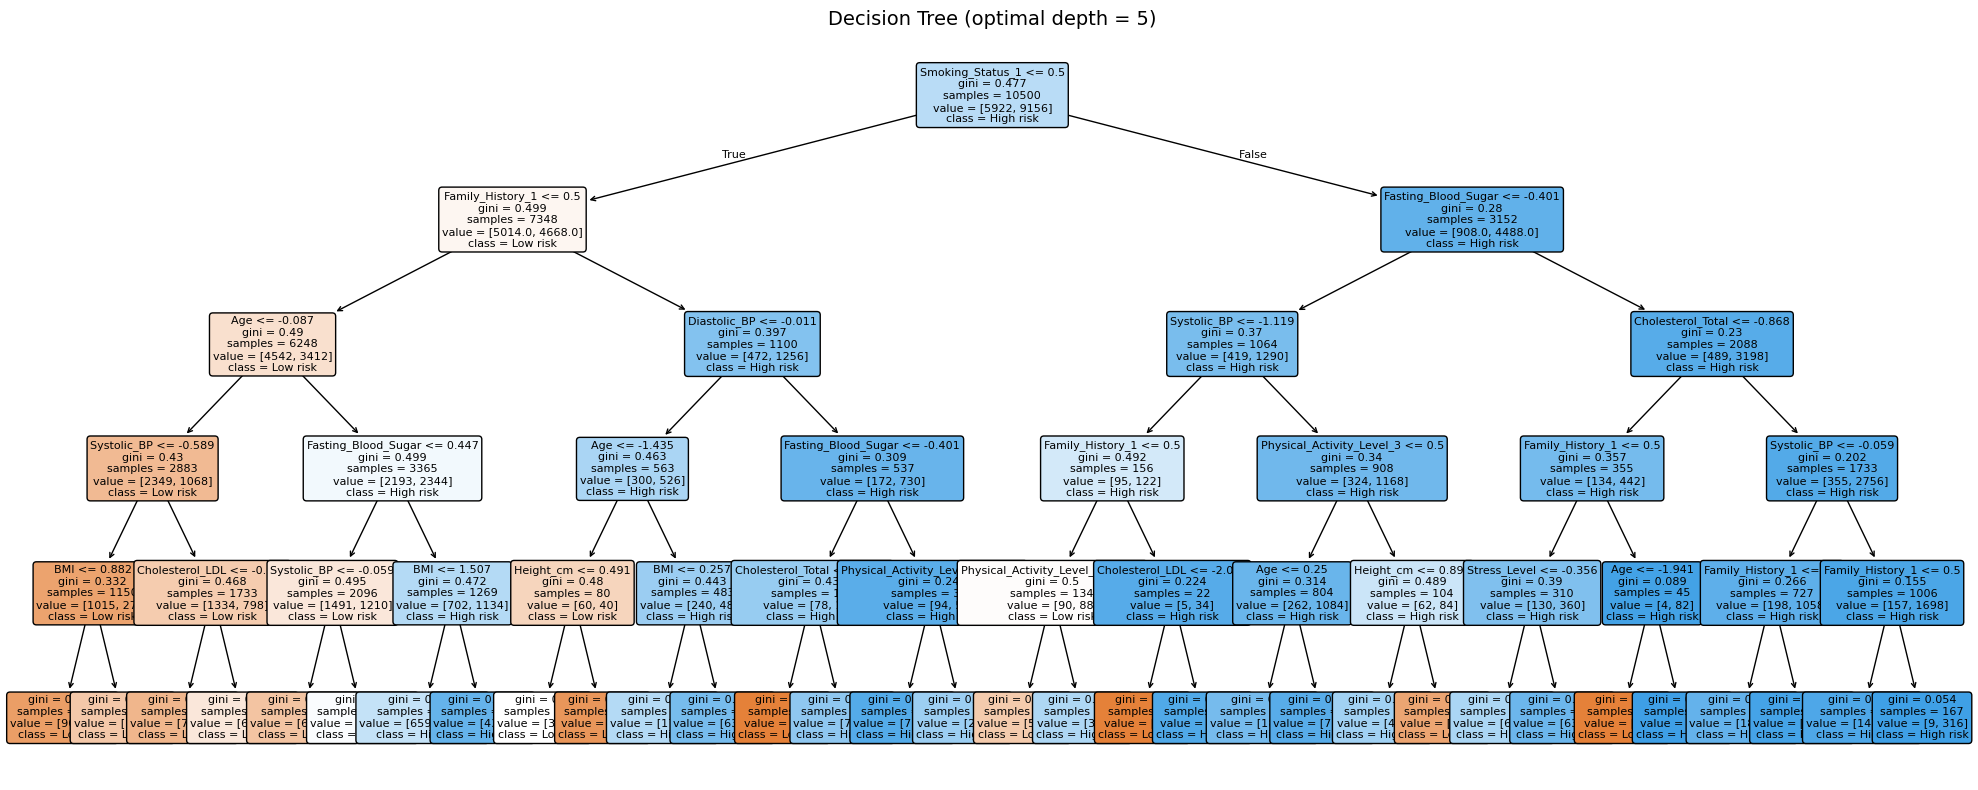

In [135]:
from sklearn.tree import plot_tree

treeG = DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'], class_weight=treeOpt.best_params_['class_weight'], random_state=42)
treeG.fit(Xtrain_c_sc, ytrain_c)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(treeG, feature_names=list(feature_names_classif),
          class_names=['Low risk', 'High risk'],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title(f"Decision Tree (optimal depth = {treeOpt.best_params_['max_depth']})", fontsize=14)
plt.tight_layout()
plt.show()

The visualized decision tree allows us to identify the most discriminating variables at the first nodes. These variables are consistent with the results of logistic regression and the exploratory analysis.odes. These variables are consistent with the results of logistic regression and the exploratory analysis.

## 1.5 Random Forest

The random forest is an ensemble method that aggregates predictions from `n_estimators` decision trees trained on random subsamples of data and variables. It reduces variance compared to a single tree. The hyperparameters `max_features` (number of variables randomly drawn at each node), `max_depth` (the highest depth of each tree),`n_estimators`, and `class_weight` is optimized by cross-validation, which reduces correlation between trees and improves generalization.

In [119]:
from sklearn.ensemble import RandomForestClassifier

ts = time.time()
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_rf_val = rf.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_rf_val)

y_proba_rf = rf.predict_proba(Xtest_c_sc)[:, 1]
metrics_rf = evaluate_with_threshold(ytest_c, y_proba_rf, best_threshold)

print("Random Forest")
print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_rf['recall']:.4f}")
print(f"Precision : {metrics_rf['precision']:.4f}")
print(f"F1-score : {metrics_rf['f1']:.4f}")
print(f"F2-score : {metrics_rf['f2']:.4f}")

Random Forest
Time: 0.64 seconds
Optimal threshold: 0.3737
Recall : 0.7870
Precision : 0.6050
F1-score : 0.6841
F2-score : 0.7423


In [120]:
y_pred_opt = (y_proba_rf >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,765,504
High risk,209,772


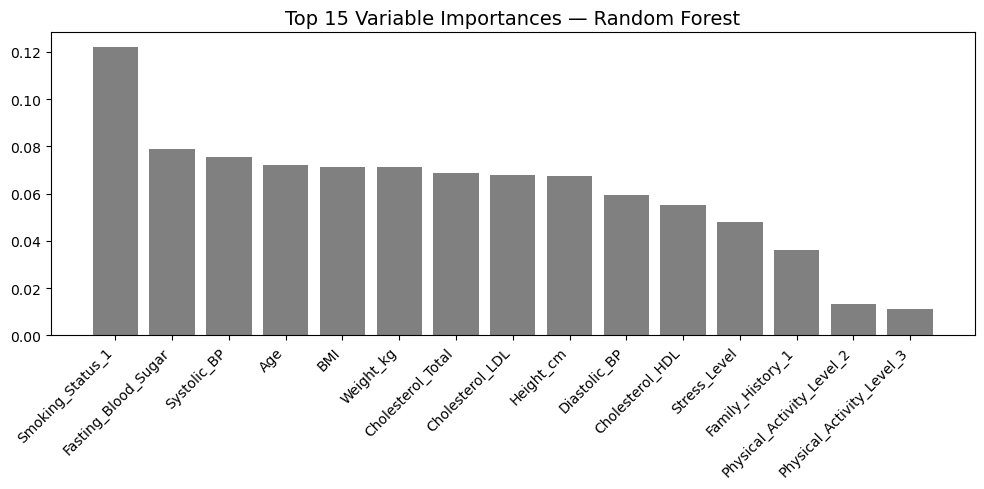

In [121]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances[indices], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_classif[indices], rotation=45, ha='right')
ax.set_title(u"Top 15 Variable Importances — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

The variable importance plot confirms the results of the exploratory analysis. The most important variables are consistent with those identified by logistic regression and the decision tree.ariables are consistent with those identified by logistic regression and the decision tree.

### Optimization of hyperparameters by cross-validation

The hyperparameters `max_features`, `max_depth`, `n_estimators`, and `class_weight` will be optimized by CV 5-fold.

In [ ]:
ts = time.time()
param_rf = [{"max_features": list(range(2, 12, 2)), "max_depth": [3, 5, 7, 10, None], "class_weight": [
                None,
                "balanced",
                {0: 1, 1: 1.5},
                {0: 1, 1: 2},
                {0: 1, 1: 2.5},
                {0: 1, 1: 3}
            ], 
            "n_estimators": [100, 200, 300]}]
rf_cv = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
                     param_rf, cv=5, n_jobs=-1, scoring=f1_scorer)
rfOpt = rf_cv.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Best score = %f, Best parameter = %s" % (rfOpt.best_score_, rfOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best score = 0.700885, Best parameter = {'class_weight': {0: 1, 1: 2}, 'max_depth': 10, 'max_features': 4}
Time: 207.85 seconds


In [137]:
y_proba_rf_opt_val = rfOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold_rf_opt, _ = find_optimal_threshold_f1(yval_c, y_proba_rf_opt_val)
y_proba_rf_opt = rfOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_rf_opt = evaluate_with_threshold(ytest_c, y_proba_rf_opt, best_threshold_rf_opt)

print("Random Forest (optimized max_features)")
print(f"Optimal threshold: {best_threshold_rf_opt:.4f}")
print(f"Recall    : {metrics_rf_opt['recall']:.4f}")
print(f"Precision : {metrics_rf_opt['precision']:.4f}")
print(f"F1-score  : {metrics_rf_opt['f1']:.4f}")
print(f"F2-score  : {metrics_rf_opt['f2']:.4f}")
y_pred_rf_opt = (y_proba_rf_opt >= best_threshold_rf_opt).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_rf_opt), index=labels_risk, columns=labels_risk)

Random Forest (optimized max_features)
Optimal threshold: 0.4848
Recall    : 0.8084
Precision : 0.5900
F1-score  : 0.6822
F2-score  : 0.7527

Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,718,551
High risk,188,793


## 1.6 Gradient Boosting

Gradient Boosting sequentially builds decision trees, each one correcting the errors of the previous one. It is a more powerful method than random forest but more sensitive to overfitting. The hyperparameters `n_estimators`, `learning_rate`, `max_depth` and `max_features` are optimized by cross-validation.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

ts = time.time()
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_gb_val = gb.predict_proba(Xval_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_gb_val)

y_proba_gb = gb.predict_proba(Xtest_c_sc)[:, 1]
metrics_gb = evaluate_with_threshold(ytest_c, y_proba_gb, best_threshold)

print("Gradient Boosting (optimized)")
print(f"Time: {te-ts:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_gb['recall']:.4f}")
print(f"Precision : {metrics_gb['precision']:.4f}")
print(f"F1-score : {metrics_gb['f1']:.4f}")
print(f"F2-score : {metrics_gb['f2']:.4f}")


Gradient Boosting (optimized)
Time: 3.51 seconds
Optimal threshold: 0.3939
Recall : 0.7472
Precision : 0.6341
F1-score : 0.6860
F2-score : 0.7215


In [20]:
y_pred_opt = (y_proba_gb >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,846,423
High risk,248,733


In [21]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.01, 0.03, 0.05, 0.1], "max_depth": [2, 3, 4, 5], 
          "max_features": [0.7, 0.8, 1.0]}]
gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param, cv=5, n_jobs=-1, scoring=f1_scorer)
gbOpt = gb.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Best score = %f, Best parameter = %s" % (gbOpt.best_score_, gbOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Best score = 0.678389, Best parameter = {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 0.7, 'n_estimators': 200}
Time: 211.40 seconds


In [22]:
yChap = gbOpt.predict(Xtest_c_sc)          # why here no check for best threshhold as we did in other sections?
print("Score on test set: %f" % gbOpt.score(Xtest_c_sc, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score on test set: 0.665956


,Low risk,High risk
Low risk,998,271
High risk,356,625


In [23]:
y_proba_gb_opt_val = gbOpt.predict_proba(Xval_c_sc)[:, 1]
best_threshold_gb_opt, _ = find_optimal_threshold_f1(yval_c, y_proba_gb_opt_val)

y_proba_gb_opt = gbOpt.predict_proba(Xtest_c_sc)[:, 1]
metrics_gb_opt = evaluate_with_threshold(ytest_c, y_proba_gb_opt, best_threshold_gb_opt)
print("Gradient Boosting (optimized)")
print(f"Optimal threshold: {best_threshold_gb_opt:.4f}")
print(f"Recall    : {metrics_gb_opt['recall']:.4f}")
print(f"Precision : {metrics_gb_opt['precision']:.4f}")
print(f"F1-score  : {metrics_gb_opt['f1']:.4f}")
print(f"F2-score  : {metrics_gb_opt['f2']:.4f}")

Gradient Boosting (optimized)
Optimal threshold: 0.3636
Recall    : 0.7737
Precision : 0.6221
F1-score  : 0.6897
F2-score  : 0.7378


In [24]:
# final confusion matrix with optimal threshold
yChap = y_proba_gb_opt > best_threshold_gb_opt        
print("Score on test set: %f" % gbOpt.score(Xtest_c_sc, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score on test set: 0.665956


,Low risk,High risk
Low risk,808,461
High risk,222,759


In [144]:
resultats_classif = pd.DataFrame({
    "Model": [
        "Logistic Regression (LASSO)",
        "Logistic Regression (Ridge)",
        "Logistic Regression",
        "Linear SVM",
        "Gaussian kernel SVM (optimized)",
        "kNN (optimized)",
        "kNN fewer variables",
        "Gradient Boosting (optimized)",
        "Random Forest",
        "Random Forest (max_features opt.)",
    ],
    "Threshold": [
        metrics_lasso['threshold'],
        metrics_ridge['threshold'],
        metrics_logit['threshold'],
        metrics_svm_lin['threshold'],
        metrics_svm_rbf['threshold'],
        metrics_knn['threshold'],
        metrics_knn_var['threshold'],
        metrics_gb['threshold'],
        metrics_rf['threshold'],
        metrics_rf_opt['threshold'],
    ],
    "Recall": [
        metrics_lasso['recall'],
        metrics_ridge['recall'],
        metrics_logit['recall'],
        metrics_svm_lin['recall'],
        metrics_svm_rbf['recall'],
        metrics_knn['recall'],
        metrics_knn_var['recall'],
        metrics_gb['recall'],
        metrics_rf['recall'],
        metrics_rf_opt['recall'],
    ],
    "Precision": [
        metrics_lasso['precision'],
        metrics_ridge['precision'],
        metrics_logit['precision'],
        metrics_svm_lin['precision'],
        metrics_svm_rbf['precision'],
        metrics_knn['precision'],
        metrics_knn_var['precision'], 
        metrics_gb['precision'],
        metrics_rf['precision'],
        metrics_rf_opt['precision'],
    ],
    "F1": [
        metrics_lasso['f1'],
        metrics_ridge['f1'],
        metrics_logit['f1'],
        metrics_svm_lin['f1'],
        metrics_svm_rbf['f1'],
        metrics_knn['f1'],
        metrics_knn_var['f1'],
        metrics_gb['f1'],
        metrics_rf['f1'],
        metrics_rf_opt['f1'],
    ],
    "F2": [
        metrics_lasso['f2'],
        metrics_ridge['f2'],
        metrics_logit['f2'],
        metrics_svm_lin['f2'],
        metrics_svm_rbf['f2'],
        metrics_knn['f2'],
        metrics_knn_var['f2'],
        metrics_gb['f2'],
        metrics_rf['f2'],
        metrics_rf_opt['f2'],
    ]
}).sort_values("F1", ascending=False).reset_index(drop=True)

print("\nModel comparison with F1-optimized threshold")
resultats_classif_display = resultats_classif.copy()
for col in ["Threshold", "Recall", "Precision", "F1", "F2"]:
    resultats_classif_display[col] = resultats_classif_display[col].map("{:.4f}".format)
display(resultats_classif_display)

print("\nF1-score gives more weight to recall (detection of at-risk patients)")
print("Meilleur modèle :", resultats_classif.iloc[0]["Model"])


Model comparison with F1-optimized threshold


,Model,Threshold,Recall,Precision,F1,F2
0,Logistic Regression (LASSO),0.3535,0.7849,0.6235,0.6949,0.7463
1,Logistic Regression (Ridge),0.3636,0.7757,0.6279,0.6940,0.7408
2,Logistic Regression,0.3636,0.7757,0.6279,0.6940,0.7408
3,Linear SVM,0.3535,0.7778,0.6229,0.6917,0.7409
4,Gaussian kernel SVM (optimized),0.3636,0.7798,0.6194,0.6904,0.7414
5,Gradient Boosting (optimized),0.3939,0.7472,0.6341,0.6860,0.7215
6,Random Forest,0.3737,0.7870,0.6050,0.6841,0.7423
7,Random Forest (max_features opt.),0.4848,0.8084,0.5900,0.6822,0.7527
8,kNN fewer variables,0.2727,0.7798,0.5787,0.6644,0.7291
9,kNN (optimized),0.3030,0.8461,0.5240,0.6472,0.7534



F1-score gives more weight to recall (detection of at-risk patients)
Meilleur modèle : Logistic Regression (LASSO)


## 1.7 Stacking with All Models

Stacking combines predictions from several base models via a meta-classifier (logistic regression). Each base model is trained with `BaggingClassifier` on data subsets to reduce variance. This approach seeks to exploit the complementarity of the different algorithms.

**Warning**: training this model takes a very long time. A save and load mechanism is implemented (`TRAIN = False` to load a pre-trained model).

### Warning: this took hours to run!

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

estimators = [("lasso",BaggingClassifier(LogisticRegression(penalty="l2",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
               ("ridge",BaggingClassifier(LogisticRegression(penalty="l1",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),

               ("kNN", BaggingClassifier(KNeighborsClassifier(), n_estimators = 20, random_state = 42)),
               
               ("boosting", GradientBoostingClassifier(n_estimators=20, learning_rate=0.05,
                                                        max_depth=3, random_state=42)),

               ("svm_gaus", BaggingClassifier(SVC(C=5, gamma=0.01, probability=True, random_state=42),
                                               n_estimators=20, random_state=42)),
            
               ("forets", RandomForestClassifier(n_estimators=20, n_jobs=1, random_state=42)),
               
               ("reg_log", BaggingClassifier(LogisticRegression(solver='liblinear', max_iter=100),
                                              n_estimators = 20, random_state=42)),
                                              
               ("svm_lin", BaggingClassifier(CalibratedClassifierCV(LinearSVC(max_iter=100, random_state=42),
                                                   method='sigmoid', cv=5), n_estimators= 20, random_state=42))]



In [86]:
import os
import time
import joblib

MODEL_PATH = "Savings/b_stacking_model.joblib"
RUNTIME_PATH = "Savings/b_stacking_results.joblib"


TRAIN = False  # TRUE == train, FALSE == load old model

if TRAIN or not os.path.exists(MODEL_PATH):
    ts = time.time()

    b_Stacking = StackingClassifier(
        estimators,
        final_estimator=LogisticRegression()
    )

    b_Stacking.fit(Xtrain_c, ytrain_c)

    te = time.time()
    runtime = te - ts

    joblib.dump(b_Stacking, MODEL_PATH)
    joblib.dump(
        {
            "runtime": runtime
        },
        RUNTIME_PATH
    )

else:
    b_Stacking = joblib.load(MODEL_PATH)
    runtime = joblib.load(RUNTIME_PATH)["runtime"]

y_proba_b_stack = b_Stacking.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_b_stack)
metrics_b_stack = evaluate_with_threshold(ytest_c, y_proba_b_stack, best_threshold)

b_weights = b_Stacking.final_estimator_.coef_[0]

for (name, _), w in zip(estimators, b_weights):
    print(f"{name}: {w:.4f}")

print("")
print("-----------------------")
print("")
print("Stacking with all Models")
print(f"Time: {runtime:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_b_stack['recall']:.4f}")
print(f"Precision : {metrics_b_stack['precision']:.4f}")
print(f"F1-score : {metrics_b_stack['f1']:.4f}")
print(f"F2-score : {metrics_b_stack['f2']:.4f}")

lasso: 1.1817
ridge: 1.3589
kNN: 0.0099
boosting: -0.0639
svm_gaus: 0.4217
forets: 0.1243
reg_log: 1.1817
svm_lin: 1.1281

-----------------------

Stacking with all Models
Temps : 1097.70 secondes
Seuil optimal : 0.2929
Recall : 0.8180
Precision : 0.6167
F1-score : 0.7033
F2-score : 0.7679


In [87]:
y_pred_opt = (y_proba_b_stack >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1027,665
Risque élevé,238,1070


A `BaggingClassifier` trains `n_estimators` (20 here) base models on different subsets of the data. The meta-classifier (logistic regression) then assigns different weights to each estimator's predictions.

## 1.8 Stacking with Top 3 Models

A simplified version of stacking is tested by keeping only the 3 best-performing models (Ridge logistic regression, LASSO and random forest), in order to reduce computation time while evaluating whether combining the best models is sufficient to obtain similar performance.

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier

top3_estimators = [("lasso",BaggingClassifier(LogisticRegression(penalty="l2",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
                   ("ridge",BaggingClassifier(LogisticRegression(penalty="l1",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
                   ("forets", RandomForestClassifier(n_estimators=20, n_jobs=1, random_state=42))]


In [89]:
import os
import time
import joblib

TOP3_MODEL_PATH = "Savings/top3_stacking_model.joblib"
TOP3_RUNTIME_PATH = "Savings/top3_stacking_results.joblib"

TRAIN = False  # TRUE == train, FALSE == load old model

if TRAIN or not os.path.exists(TOP3_MODEL_PATH):
    ts = time.time()

    top3_Stacking = StackingClassifier(
        top3_estimators,
        final_estimator=LogisticRegression()
    )

    top3_Stacking.fit(Xtrain_c, ytrain_c)

    te = time.time()
    runtime = te - ts

    joblib.dump(top3_Stacking, TOP3_MODEL_PATH)
    joblib.dump(
        {
            "runtime": runtime
        },
        TOP3_RUNTIME_PATH)

else:
    top3_Stacking = joblib.load(TOP3_MODEL_PATH)
    runtime = joblib.load(TOP3_RUNTIME_PATH)["runtime"]

y_proba_top3_stack = top3_Stacking.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_top3_stack)
metrics_top3_stack = evaluate_with_threshold(ytest_c, y_proba_top3_stack, best_threshold)

top3_weights = top3_Stacking.final_estimator_.coef_[0]

for (name, _), w in zip(top3_estimators, top3_weights):
    print(f"{name}: {w:.4f}")

print("")
print("-----------------------")
print("")
print("Stacking with all Models:")
print(f"Time: {runtime:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_top3_stack['recall']:.4f}")
print(f"Precision : {metrics_top3_stack['precision']:.4f}")
print(f"F1-score : {metrics_top3_stack['f1']:.4f}")
print(f"F2-score : {metrics_top3_stack['f2']:.4f}")

lasso: 2.3794
ridge: 2.4006
forets: 0.1576

-----------------------

Stacking with all Models:
Temps : 328.28 secondes
Seuil optimal : 0.3030
Recall : 0.8073
Precision : 0.6208
F1-score : 0.7019
F2-score : 0.7616


In [90]:
y_pred_opt = (y_proba_top3_stack >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1047,645
Risque élevé,252,1056


## 1.9 Neural Network 

The multilayer perceptron (MLP) is a non-linear model capable of learning complex representations. The main hyperparameters are the number of neurons in the hidden layer (`hidden_layer_sizes`), the activation function (`activation`) and learning rate (`alpha`), optimized by 10-fold cross-validation.

In [11]:
from sklearn.neural_network import MLPClassifier

In [20]:
ts = time.time()

param_grid = {
    "hidden_layer_sizes": [
        (16,),
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (32, 16, 8),
        (64, 32, 16)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01]
}
nnetC= GridSearchCV(MLPClassifier(max_iter=500),param_grid,cv=10,n_jobs=-1, scoring=f1_scorer)
nnetOptC=nnetC.fit(Xtrain_c, ytrain_c)
# optimal parameter

te = time.time()
runtime = te - ts

y_proba_NN_val = nnetOptC.predict_proba(Xval_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(yval_c, y_proba_NN_val)

y_proba_NN = nnetOptC.predict_proba(Xtest_c)[:, 1]
metrics_NN = evaluate_with_threshold(ytest_c, y_proba_NN, best_threshold)

print("Best score = %f, Best parameter = %s" % (nnetOptC.best_score_, nnetOptC.best_params_))
print("Time: %.2f seconds" % (te - ts))

print("")
print("Stacking with all Models:")
print(f"Time: {runtime:.2f} seconds")
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Recall : {metrics_NN['recall']:.4f}")
print(f"Precision : {metrics_NN['precision']:.4f}")
print(f"F1-score : {metrics_NN['f1']:.4f}")
print(f"F2-score : {metrics_NN['f2']:.4f}")

Best score = 0.686257, Best parameter = {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (32, 16, 8)}
Time: 186.20 seconds

Stacking with all Models:
Time: 186.20 seconds
Optimal threshold: 0.2424
Recall : 0.8298
Precision : 0.6016
F1-score : 0.6975
F2-score : 0.7713


In [21]:
y_pred_opt = (y_proba_NN >= best_threshold).astype(int)
print("\nConfusion matrix (optimal threshold):")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Confusion matrix (optimal threshold):


,Low risk,High risk
Low risk,730,539
High risk,167,814


## 1.10 Model Comparison, `Heart_Disease_Risk`

All optimized models are compared on the test set.

In [94]:
resultats_classif = pd.DataFrame({
    "Model": [
        "Logistic Regression (LASSO)",
        "Logistic Regression (Ridge)",
        "Logistic Regression",
        "Linear SVM",
        "Gaussian kernel SVM (optimized)",
        "kNN (optimized)",
        "kNN fewer variables",
        "Gradient Boosting (optimized)",
        "Random Forest",
        "Random Forest (max_features opt.)",
        "Stacking all models",
        "Stacking top 3 models",
        "Neural Network",
    ],
    "Threshold": [
        metrics_lasso['threshold'],
        metrics_ridge['threshold'],
        metrics_logit['threshold'],
        metrics_svm_lin['threshold'],
        metrics_svm_rbf['threshold'],
        metrics_knn['threshold'],
        metrics_knn_var['threshold'],
        metrics_gb['threshold'],
        metrics_rf['threshold'],
        metrics_rf_opt['threshold'],
        metrics_b_stack['threshold'],
        metrics_top3_stack['threshold'],
        metrics_NN['threshold'],
    ],
    "Recall": [
        metrics_lasso['recall'],
        metrics_ridge['recall'],
        metrics_logit['recall'],
        metrics_svm_lin['recall'],
        metrics_svm_rbf['recall'],
        metrics_knn['recall'],
        metrics_knn_var['recall'],
        metrics_gb['recall'],
        metrics_rf['recall'],
        metrics_rf_opt['recall'],
        metrics_b_stack['recall'],
        metrics_top3_stack['recall'],
        metrics_NN['recall'],
    ],
    "Precision": [
        metrics_lasso['precision'],
        metrics_ridge['precision'],
        metrics_logit['precision'],
        metrics_svm_lin['precision'],
        metrics_svm_rbf['precision'],
        metrics_knn['precision'],
        metrics_knn_var['precision'], 
        metrics_gb['precision'],
        metrics_rf['precision'],
        metrics_rf_opt['precision'],
        metrics_b_stack['precision'],
        metrics_top3_stack['precision'],
        metrics_NN['precision'],
    ],
    "F1": [
        metrics_lasso['f1'],
        metrics_ridge['f1'],
        metrics_logit['f1'],
        metrics_svm_lin['f1'],
        metrics_svm_rbf['f1'],
        metrics_knn['f1'],
        metrics_knn_var['f1'],
        metrics_gb['f1'],
        metrics_rf['f1'],
        metrics_rf_opt['f1'],
        metrics_b_stack['f1'],
        metrics_top3_stack['f1'],
        metrics_NN['f1'],
    ],
    "F2": [
        metrics_lasso['f2'],
        metrics_ridge['f2'],
        metrics_logit['f2'],
        metrics_svm_lin['f2'],
        metrics_svm_rbf['f2'],
        metrics_knn['f2'],
        metrics_knn_var['f2'],
        metrics_gb['f2'],
        metrics_rf['f2'],
        metrics_rf_opt['f2'],
        metrics_b_stack['f2'],
        metrics_top3_stack['f2'],
        metrics_NN['f2'],
    ]
}).sort_values("F2", ascending=False).reset_index(drop=True)

print("\nModel comparison with F1-optimized threshold")
resultats_classif_display = resultats_classif.copy()
for col in ["Threshold", "Recall", "Precision", "F1", "F2"]:
    resultats_classif_display[col] = resultats_classif_display[col].map("{:.4f}".format)
display(resultats_classif_display)

print("\nF2-score gives more weight to recall (detection of at-risk patients)")
print("Meilleur modèle :", resultats_classif.iloc[0]["Model"])


Comparaison des modèles avec seuil optimisé sur F1


,Modèle,Seuil,Recall,Precision,F1,F2
0,Régression logistique (Ridge),0.2828,0.8540,0.5948,0.7012,0.7855
1,Régression logistique (LASSO),0.3030,0.8295,0.6072,0.7011,0.7729
2,Stack Boosting de toutes les models,0.2929,0.8180,0.6167,0.7033,0.7679
3,Gradient Boosting (optimisé),0.3333,0.8089,0.6227,0.7037,0.7632
4,Stack Boosting avec les top 3 models,0.3030,0.8073,0.6208,0.7019,0.7616
5,SVM noyau gaussien (optimisé),0.2929,0.7959,0.6222,0.6984,0.7538
6,kNN (optimisé),0.3535,0.8127,0.5831,0.6790,0.7534
7,knn moins de variables,0.3131,0.8043,0.5994,0.6869,0.7528
8,Régression logistique,0.3434,0.7913,0.6296,0.7012,0.7526
9,Forêt aléatoire (max_features opt.),0.3737,0.7905,0.6274,0.6996,0.7515



Le F2-score donne plus de poids au recall (détection des malades)
Meilleur modèle : Régression logistique (Ridge)


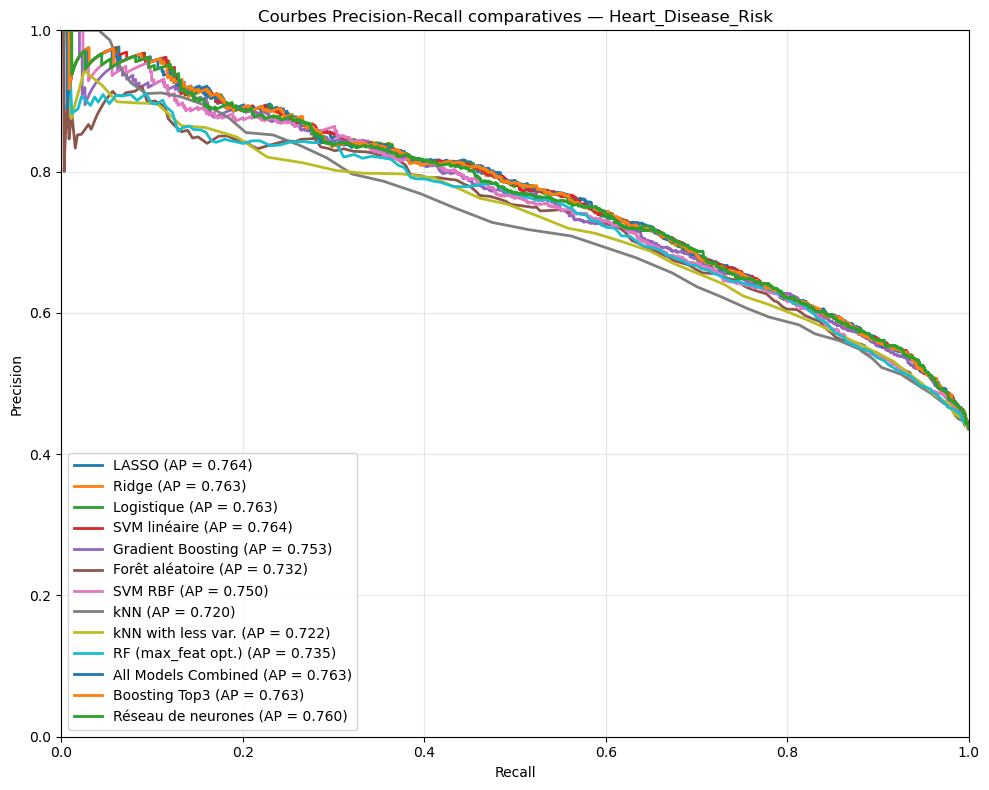

In [95]:
# =============================================================================
# Courbes Precision-Recall comparatives
# =============================================================================

plt.figure(figsize=(10, 8))

models_probas = [y_proba_lasso, y_proba_ridge, y_proba_logit, y_proba_svm_lin, 
                 y_proba_gb, y_proba_rf, y_proba_svm_rbf, y_proba_knn, y_proba_knn_var, 
                 y_proba_rf_opt, y_proba_b_stack, y_proba_top3_stack, y_proba_NN]
models_names = ["LASSO", "Ridge", "Logistic", "Linear SVM", 
                "Gradient Boosting", "Random Forest", "SVM RBF", "kNN","kNN with less var.", "RF (max_feat opt.)",
                "All Models Combined", "Boosting Top3", "Neural Network"]

for proba, name in zip(models_probas, models_names):
    precision, recall, _ = precision_recall_curve(ytest_c, proba)
    ap = average_precision_score(ytest_c, proba)
    plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparative Precision-Recall Curves — Heart_Disease_Risk')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

### Comparative ROC Curves

ROC (Receiver Operating Characteristic) curves represent the true positive rate as a function of the false positive rate for different decision thresholds. The area under the curve (AUC-ROC) allows comparing models independently of the chosen threshold.

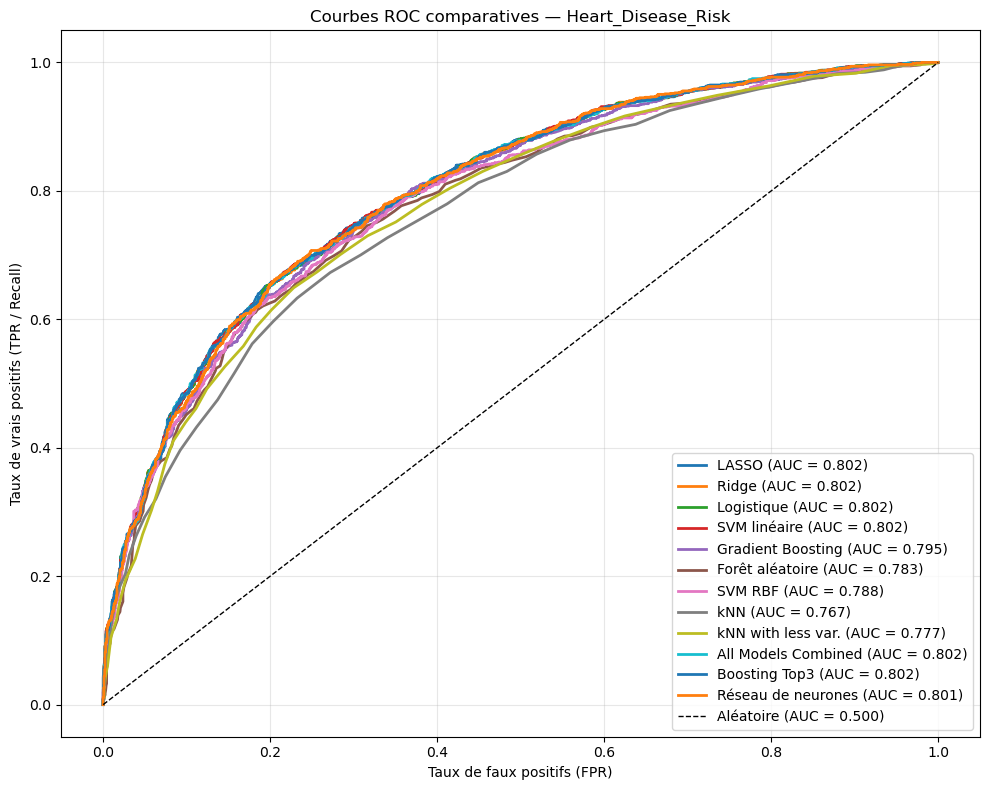

In [96]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

models_probas_roc = [
    (y_proba_lasso,   "LASSO"),
    (y_proba_ridge,   "Ridge"),
    (y_proba_logit,   "Logistic"),
    (y_proba_svm_lin, "Linear SVM"),
    (y_proba_gb,      "Gradient Boosting"),
    (y_proba_rf,      "Random Forest"),
    (y_proba_svm_rbf, "SVM RBF"),
    (y_proba_knn,     "kNN"),
    (y_proba_knn_var, "kNN with less var."),
    (y_proba_b_stack, "All Models Combined"),
    (y_proba_top3_stack, "Boosting Top3"),
    (y_proba_NN, "Neural Network")
]

for proba, name in models_probas_roc:
    fpr, tpr, _ = roc_curve(ytest_c, proba)
    auc = roc_auc_score(ytest_c, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Comparative ROC Curves — Heart_Disease_Risk')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature analysis

In this section, the importance and the influence of the features will be analyzed, using Permutation Importance, PDP and ICE.

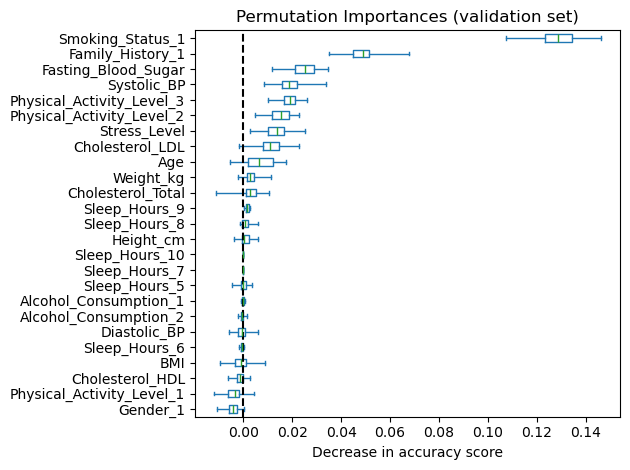

In [29]:
from sklearn.inspection import permutation_importance
# Permutation importance for gradient boosting
result = permutation_importance(gbOpt, Xval_c_sc, yval_c, n_repeats=50, random_state=42, n_jobs=-1)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=Xval_c_sc.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (validation set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

**Comments**: we found the same important features as in exploration, including Smoking status, Family history, Fasting blood sugar, Systolic BP, Physical level activity.

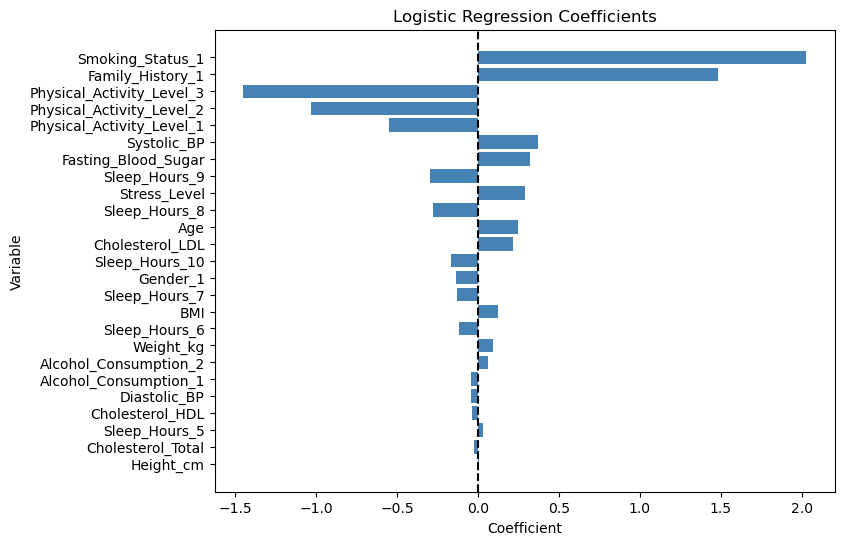

In [32]:
# Coefficients for logistic regression

feature_names = Xtrain_c_sc.columns  # or list of features used

# Get coefficients
coefs = logit.coef_[0]

# Put into DataFrame
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefs
})

# Sort by absolute value
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df['Variable'], coef_df['Coefficient'], color='steelblue')
plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Coefficient')
plt.ylabel('Variable')
plt.title('Logistic Regression Coefficients')
plt.gca().invert_yaxis()  # largest on top
plt.show()

## Model comparison, Heart_Disease_Risk

The F2-score is used as the primary ranking metric, as it gives more weight to recall, which is critical in a medical context where missing an at-risk patient is more costly than a false alarm.

The best model by F2-score is **Ridge Logistic Regression** with F2 = 0.786 and Recall = 0.854, followed closely by LASSO Logistic Regression with F2 = 0.773 and Stacking with all models with F2 = 0.768. Non-linear models such as Gradient Boosting and SVM RBF perform comparably, confirming that the relationships in this dataset are largely captured by linear models.

The improvement brought by non-linear models is modest, less than 3 points of F2, which suggests that the main structure of the data is well captured by logistic regression.

If an interpretability constraint is added, Ridge or LASSO logistic regression are the best choices: their coefficients are directly readable and confirm the EDA findings, with Smoking_Status, Family_History, Physical_Activity_Level and Stress_Level as the most influential variables. The decision tree is also a good interpretable alternative.

These results are coherent with the exploratory analysis: the variables identified as most associated with heart disease risk in the EDA are indeed the ones that drive model performance.

# 2 Prediction of `Cholesterol_LDL`

## 2.1 Data Preparation, Regression

In [48]:
y_reg = df_encoded["Cholesterol_LDL"].values
X_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).values
feature_names_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).columns

Xtrain_r, Xtest_r, ytrain_r, ytest_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xtrain_r_sc = scaler_r.fit_transform(Xtrain_r)
Xtest_r_sc  = scaler_r.transform(Xtest_r)

print("Training set:", Xtrain_r.shape[0], "observations")
print("Test set:     ", Xtest_r.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


The variable `Heart_Disease_Risk` is excluded from the explanatory variables for the prediction of `Cholesterol_LDL`, as it is a distinct target variable and not an explanatory variable available in practice. The same train/test split (80%/20%) is used. The metrics are **R²** (coefficient of determination) and **RMSE** (root mean squared error).

In [49]:
feature_names_reg

Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Cholesterol_Total', 'Cholesterol_HDL', 'Fasting_Blood_Sugar',
       'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1',
       'Physical_Activity_Level_2', 'Physical_Activity_Level_3',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1',
       'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5',
       'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10'],
      dtype='object')

## 2.2 Linear Models

### 2.2.1 Linear Regression

#### Without regularization

In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

ts = time.time()
lr = LinearRegression()
lr.fit(Xtrain_r, ytrain_r)
ypred = lr.predict(Xtest_r)
te = time.time()

print("R² test: %f" % r2_score(ytest_r, ypred))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Execution time: %.2f seconds" % (te - ts))

R² test : 0.693690
RMSE test : 9.796619
Temps d'exécution : 0.02 secondes


 Linear regression without regularization serves as the baseline model. The R² and RMSE on the test set provide a reference to compare with more complex models.


#### Ridge regularization (L2)



In [51]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
ridge = GridSearchCV(Ridge(), param, cv=5, n_jobs=1, scoring='r2')
ridgeOpt = ridge.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (ridgeOpt.best_score_, ridgeOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.685860, Meilleur paramètre = {'alpha': 100}
Temps : 0.18 secondes


In [52]:
yChap = ridgeOpt.predict(Xtest_r)
print("R² test (Ridge): %f" % r2_score(ytest_r, yChap))
print("RMSE test (Ridge): %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (Ridge) : 0.693849
RMSE test (Ridge) : 9.794086


Ridge regularization penalizes the coefficients without setting any to zero. The hyperparameter `alpha` is optimized by 5-fold cross-validation by maximizing R².pha` is optimized by 5-fold cross-validation by maximizing R².

#### LASSO regularization (L1) and variable selection

In [53]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
lasso = GridSearchCV(Lasso(max_iter=5000), param, cv=5, n_jobs=1, scoring='r2')
lassoOpt = lasso.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (lassoOpt.best_score_, lassoOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.686743, Meilleur paramètre = {'alpha': 1}
Temps : 0.32 secondes


In [54]:
yChap = lassoOpt.predict(Xtest_r)
print("R² test (LASSO): %f" % r2_score(ytest_r, yChap))
print("RMSE test (LASSO): %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (LASSO) : 0.694489
RMSE test (LASSO) : 9.783834


In [55]:
coef_lasso = lassoOpt.best_estimator_.coef_
variables_selectionnees_r = feature_names_reg[coef_lasso != 0]
print("Variables selected by LASSO (%d / %d):" % (len(variables_selectionnees_r), len(feature_names_reg)))
print(variables_selectionnees_r.tolist())

Variables sélectionnées par le LASSO (3 / 32) :
['Age', 'Systolic_BP', 'Cholesterol_Total']


The LASSO selects only 3 variables out of 32: Age, Systolic_BP and Cholesterol_Total. This is strongly consistent with the EDA conclusions, which identified Age and Cholesterol_Total as the most correlated variables with Cholesterol_LDL, and Systolic_BP as a secondary predictor. Stress_Level and Sleep_Hours are not selected, which confirms the EDA observation that their distribution is virtually identical across all levels of Cholesterol_LDL.

LASSO performs automatic variable selection. The retained variables correspond to the predictors most directly related to LDL cholesterol, which is consistent with the medical literature: age, total cholesterol and blood pressure.

## 2.3 kNN (Regression)

The k-nearest neighbors regressor (`KNeighborsRegressor`) predicts the target value as the average of the `k` nearest neighbors. The hyperparameter `k` is optimized by cross-validation. Data is standardized beforehand.

In [56]:
from sklearn.neighbors import KNeighborsRegressor

ts = time.time()
param_grid_r = [{"n_neighbors": list(range(1, 21))}]
knn_r = GridSearchCV(KNeighborsRegressor(), param_grid_r, cv=10, n_jobs=1, scoring='r2')
knnROpt = knn_r.fit(Xtrain_r_sc, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (knnROpt.best_score_, knnROpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.368661, Meilleur paramètre = {'n_neighbors': 20}
Temps : 2.25 secondes


R² test (kNN) : 0.378929
RMSE test (kNN) : 13.949750


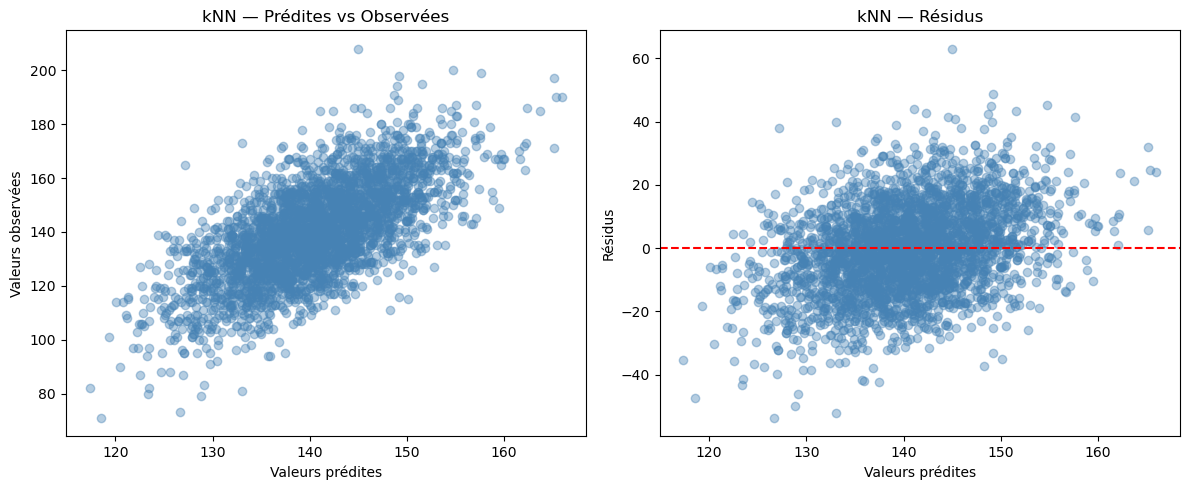

In [57]:
yChap_knn_r = knnROpt.predict(Xtest_r_sc)
print("R² test (kNN): %f" % r2_score(ytest_r, yChap_knn_r))
print("RMSE test (kNN): %f" % np.sqrt(mean_squared_error(ytest_r, yChap_knn_r)))

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_knn_r, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Observed values")
axes[0].set_title("kNN — Predicted vs Observed")

axes[1].scatter(yChap_knn_r, ytest_r - yChap_knn_r, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("kNN — Residuals")

plt.tight_layout()
plt.show()

kNN regression predicts the target value as the average of the `k` nearest neighbors. Its performance is limited in the presence of many variables, which motivates the version with variable selection.

## 2.3.2 kNN Regression with Fewer Variables

In [58]:
X_reg_kNN = df_encoded.drop(columns=["Cholesterol_LDL", 'Height_cm', 'Weight_kg', 'BMI', 'Diastolic_BP',
       'Cholesterol_HDL', 'Fasting_Blood_Sugar',
       'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1',
       'Physical_Activity_Level_2', 'Physical_Activity_Level_3',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1',
       'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5',
       'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10' ]).values.copy()

# Here we keep the Variables only based on the PCA of the numerical Variables: Cholesterol Total, Stylostic BP, Age

Xtrain_r_kNN, Xtest_r_kNN, ytrain_r, ytest_r = train_test_split(
    X_reg_kNN, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xtrain_r_sc_kNN = scaler_r.fit_transform(Xtrain_r_kNN)
Xtest_r_sc_kNN  = scaler_r.transform(Xtest_r_kNN)

print("Training set:", Xtrain_r_kNN.shape[0], "observations")
print("Test set:     ", Xtest_r_kNN.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


In [59]:
from sklearn.neighbors import KNeighborsRegressor

ts = time.time()
param_grid_r = [{"n_neighbors": list(range(1, 100))}]
knn_var_r = GridSearchCV(KNeighborsRegressor(), param_grid_r, cv=10, n_jobs=1, scoring='r2')
knn_var_ROpt = knn_var_r.fit(Xtrain_r_sc_kNN, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (knn_var_ROpt.best_score_, knn_var_ROpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.671303, Meilleur paramètre = {'n_neighbors': 37}
Temps : 11.01 secondes


R² test (kNN) : 0.676031
RMSE test (kNN) : 10.075053


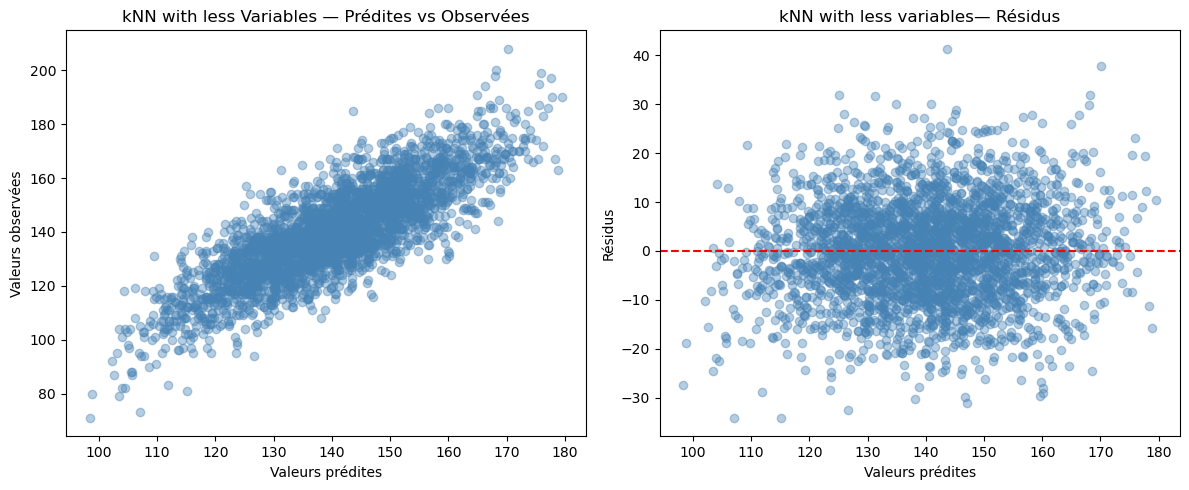

In [60]:
yChap_knn_var_r = knn_var_ROpt.predict(Xtest_r_sc_kNN)
print("R² test (kNN): %f" % r2_score(ytest_r, yChap_knn_var_r))
print("RMSE test (kNN): %f" % np.sqrt(mean_squared_error(ytest_r, yChap_knn_var_r)))

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_knn_var_r, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Observed values")
axes[0].set_title("kNN with less Variables — Predicted vs Observed")

axes[1].scatter(yChap_knn_var_r, ytest_r - yChap_knn_var_r, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("kNN with less variables — Residuals")

plt.tight_layout()
plt.show()

Reducing to the variables most correlated with `Cholesterol_LDL`, identified by PCA as total cholesterol, systolic blood pressure and age, noticeably improves kNN performance by reducing noise from uninformative variables.

We can observe a real improvement compared to kNN on all variables.

## 2.4 SVR

### 2.4.1 Linear SVR

SVR (Support Vector Regression) adapts the SVM principle to regression. Two variants are compared: linear SVR and Gaussian kernel SVR (RBF). The RBF kernel is justified if non-linear relationships exist between the variables and `Cholesterol_LDL`. The hyperparameters `C` and `gamma` are optimized by cross-validation.

In [61]:
from sklearn.svm import LinearSVR

ts = time.time()
method = LinearSVR(max_iter=5000)
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test: %f" % r2_score(ytest_r, ypred))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Execution time: %.2f seconds" % (te - ts))

R² test : 0.693354
RMSE test : 9.801999
Temps d'exécution : 0.03 secondes


### 2.4.2 Gaussian Kernel SVR

In [62]:
from sklearn.svm import SVR

ts = time.time()
method = SVR(gamma='auto')
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test: %f" % r2_score(ytest_r, ypred))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Execution time: %.2f seconds" % (te - ts))

R² test : 0.647474
RMSE test : 10.509731
Temps d'exécution : 4.20 secondes


In [63]:
ts = time.time()
param = [{"C": [1, 5, 10], "gamma": [0.001, 0.01, 0.1]}]
svr = GridSearchCV(SVR(), param, cv=5, n_jobs=1, scoring='r2')
svrOpt = svr.fit(Xtrain_r_sc, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (svrOpt.best_score_, svrOpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.680925, Meilleur paramètre = {'C': 10, 'gamma': 0.001}
Temps : 124.51 secondes


In [64]:
yChap = svrOpt.predict(Xtest_r_sc)
print("R² test (SVR RBF optimized): %f" % r2_score(ytest_r, yChap))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (SVR RBF optimisé) : 0.690313
RMSE test : 9.850485


The Gaussian kernel SVR improves performance compared to the linear SVR. The parameters `C` and `gamma` were determined by cross-validation.

## 2.5 Optimal Decision Tree


The decision tree in regression partitions the variable space to minimize intra-node variance. Its depth is optimized by cross-validation. It offers good interpretability but is prone to overfitting without a depth constraint.

In [65]:
from sklearn.tree import DecisionTreeRegressor

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None]}]
tree_r = GridSearchCV(DecisionTreeRegressor(random_state=42), param, cv=5, n_jobs=1, scoring='r2')
treeROpt = tree_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (treeROpt.best_score_, treeROpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.679484, Meilleur paramètre = {'max_depth': 5}
Temps : 1.23 secondes


In [66]:
yChap = treeROpt.predict(Xtest_r)
print("R² test: %f" % r2_score(ytest_r, yChap))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test : 0.687738
RMSE test : 9.891349


## 2.6 Random Forest



The random forest in regression aggregates predictions from `n_estimators` trees. It reduces variance compared to a single tree and provides a variable importance measure, useful for interpretation.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

ts = time.time()
method = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test: %f" % r2_score(ytest_r, ypred))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Execution time: %.2f seconds" % (te - ts))

R² test : 0.675677
RMSE test : 10.080556
Temps d'exécution : 9.83 secondes


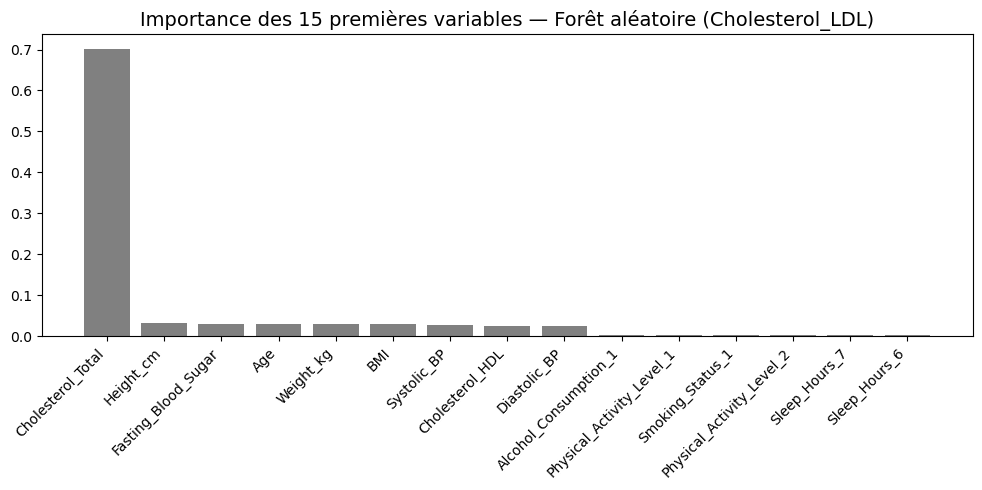

In [68]:
importances_r = method.feature_importances_
indices_r = np.argsort(importances_r)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances_r[indices_r], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_reg[indices_r], rotation=45, ha='right')
ax.set_title(u"Top 15 Variable Importances — Random Forest (Cholesterol_LDL)", fontsize=14)
plt.tight_layout()
plt.show()

The most important variables for predicting `Cholesterol_LDL` are consistent with the exploratory analysis. Stress and sleep hours appear unimportant, which confirms the observations from the density plots in the EDA.

## 2.7 Gradient Boosting

Gradient Boosting in regression sequentially builds trees that correct the residuals of the previous model. The hyperparameters `n_estimators`, `learning_rate` and `max_depth` are optimized by cross-validation.

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

ts = time.time()
method = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test: %f" % r2_score(ytest_r, ypred))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Execution time: %.2f seconds" % (te - ts))

R² test : 0.684023
RMSE test : 9.950005
Temps d'exécution : 3.32 secondes


In [70]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}]
gb_r = GridSearchCV(GradientBoostingRegressor(random_state=42), param, cv=5, n_jobs=1, scoring='r2')
gbROpt = gb_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Best score = %f, Best parameter = %s" % (gbROpt.best_score_, gbROpt.best_params_))
print("Time: %.2f seconds" % (te - ts))

Meilleur score = 0.683337, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Temps : 80.46 secondes


In [71]:
yChap = gbROpt.predict(Xtest_r)
print("R² test (optimized): %f" % r2_score(ytest_r, yChap))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (optimisé) : 0.691548
RMSE test : 9.830823


## 2.8 Neural Network

The MLP neural network in regression is trained with the same architecture as for classification. The number of neurons in the hidden layer is optimized by 10-fold cross-validation.

In [72]:
from sklearn.neural_network import MLPRegressor

In [ ]:
param_grid=[{"hidden_layer_sizes":list([(5,),(6,),(7,),(8,),(12,),(15,)])}]
nnetR= GridSearchCV(MLPRegressor(max_iter=500),param_grid,cv=10,n_jobs=-1)
nnetOptR=nnetR.fit(Xtrain_r, ytrain_r)
# optimal parameter
print("Best score = %f, Best parameter = %s" % (1. - nnetOpt.best_score_, nnetOpt.best_params_))

Meilleur score = 0.316062, Meilleur paramètre = {'hidden_layer_sizes': (8,)}


In [ ]:
yChap_nn = nnetOptR.predict(Xtest_r)
print("R² test (optimized): %f" % r2_score(ytest_r, yChap_nn))
print("RMSE test: %f" % np.sqrt(mean_squared_error(ytest_r, yChap_nn)))

R² test (optimisé) : 0.691908
RMSE test : 9.825084


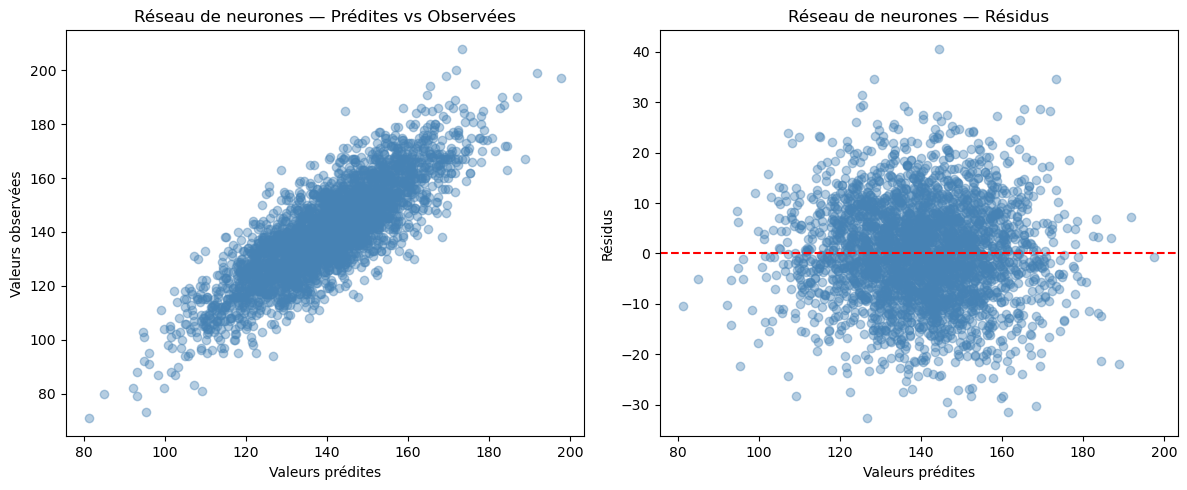

In [79]:
# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_nn, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Observed values")
axes[0].set_title("Neural Network — Predicted vs Observed")

axes[1].scatter(yChap_nn, ytest_r - yChap_nn, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Neural Network — Residuals")

plt.tight_layout()
plt.show()

## 2.9 Model Comparison, `Cholesterol_LDL`

In [ ]:
yChap_knn_r = knnROpt.predict(Xtest_r_sc)

r2_scores = [
    r2_score(ytest_r, lr.predict(Xtest_r)),
    r2_score(ytest_r, ridgeOpt.predict(Xtest_r)),
    r2_score(ytest_r, lassoOpt.predict(Xtest_r)),
    r2_score(ytest_r, knnROpt.predict(Xtest_r_sc)),
    r2_score(ytest_r, knn_var_ROpt.predict(Xtest_r_sc_kNN)),
    r2_score(ytest_r, LinearSVR(max_iter=5000).fit(Xtrain_r_sc, ytrain_r).predict(Xtest_r_sc)),
    r2_score(ytest_r, svrOpt.predict(Xtest_r_sc)),
    r2_score(ytest_r, treeROpt.predict(Xtest_r)),
    r2_score(ytest_r, RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42).fit(Xtrain_r, ytrain_r).predict(Xtest_r)),
    r2_score(ytest_r, gbROpt.predict(Xtest_r)),
    r2_score(ytest_r, nnetOptR.predict(Xtest_r))
]

rmse_scores = [
    np.sqrt(mean_squared_error(ytest_r, lr.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, ridgeOpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, lassoOpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, knnROpt.predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, knn_var_ROpt.predict(Xtest_r_sc_kNN))),
    np.sqrt(mean_squared_error(ytest_r, LinearSVR(max_iter=5000).fit(Xtrain_r_sc, ytrain_r).predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, svrOpt.predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, treeROpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42).fit(Xtrain_r, ytrain_r).predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, gbROpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, nnetOptR.predict(Xtest_r)))
]

resultats_reg = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (optimized)",
        "LASSO (optimized)",
        "kNN (optimized)",
        "kNN with less variables",
        "Linear SVR",
        "Gaussian kernel SVR (optimized)",
        "Decision Tree (optimized)",
        "Random Forest",
        "Gradient Boosting (optimized)",
        "Neural Network"
    ],
    "R² test": r2_scores,
    "RMSE test": rmse_scores
}).sort_values("R² test", ascending=False).reset_index(drop=True)

resultats_reg["R² test"] = resultats_reg["R² test"].map("{:.4f}".format)
resultats_reg["RMSE test"] = resultats_reg["RMSE test"].map("{:.4f}".format)
resultats_reg

,Modèle,R² test,RMSE test
0,LASSO (optimisé),0.6945,9.7838
1,Ridge (optimisé),0.6938,9.7941
2,Régression linéaire,0.6937,9.7966
3,SVR linéaire,0.6936,9.8025
4,Réseau de neurones,0.6919,9.8251
5,Gradient Boosting (optimisé),0.6915,9.8308
6,SVR noyau gaussien (optimisé),0.6903,9.8505
7,Arbre de décision (optimisé),0.6877,9.8913
8,kNN with less variables,0.6760,10.0751
9,Forêt aléatoire,0.6757,10.0806


## Model comparison, Cholesterol_LDL

The best models are LASSO and Ridge, both achieving R² = 0.694 and RMSE around 9.78, followed very closely by linear regression and linear SVR. All linear models achieve nearly identical performance, which is a strong signal that the relationship between the predictors and Cholesterol_LDL is essentially linear.

Non-linear models do not improve upon linear models, and kNN without variable selection performs significantly worse with R² = 0.379, illustrating the curse of dimensionality.

The overall R² around 0.69 is moderate, which is consistent with the EDA: only a few variables are clearly correlated with Cholesterol_LDL, and variables like Stress_Level and Sleep_Hours show virtually no predictive power, as confirmed by the LASSO selecting only 3 variables.

If an interpretability constraint is added, LASSO linear regression is the clear choice: it selects only Age, Systolic_BP and Cholesterol_Total, achieving the best R² with a minimal and interpretable model fully consistent with the EDA.